### Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

### Reading file

In [2]:
df = pd.read_table('smsspamcollection.tsv')
df.head()

,label,message,length,punct
0,ham,"Go until jurong point, crazy.. Available only ...",111,9
1,ham,Ok lar... Joking wif u oni...,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,6
3,ham,U dun say so early hor... U c already then say...,49,6
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,2


In [6]:
spam = df[df['label'] == 'spam']['message']
spam

2       Free entry in 2 a wkly comp to win FA Cup fina...
5       FreeMsg Hey there darling it's been 3 week's n...
8       WINNER!! As a valued network customer you have...
9       Had your mobile 11 months or more? U R entitle...
11      SIX chances to win CASH! From 100 to 20,000 po...
                              ...                        
5537    Want explicit SEX in 30 secs? Ring 02073162414...
5540    ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...
5547    Had your contract mobile 11 Mnths? Latest Moto...
5566    REMINDER FROM O2: To get 2.50 pounds free call...
5567    This is the 2nd time we have tried 2 contact u...
Name: message, Length: 747, dtype: object

In [5]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Spam message

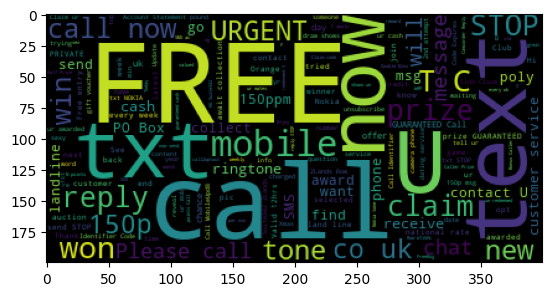

In [7]:
# import class
from wordcloud import WordCloud

# create instance
wc = WordCloud()

# generate 
wc.generate(' '.join(spam))

# show
plt.imshow(wc)
plt.show()

### ham message

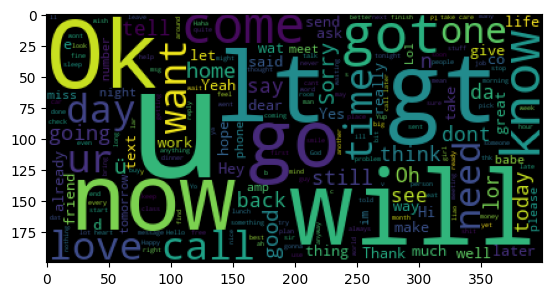

In [8]:
ham = df[df['label'] == 'ham']['message']
ham

# import class
from wordcloud import WordCloud

# create instance
wc = WordCloud()

# generate 
wc.generate(' '.join(ham))

# show
plt.imshow(wc)
plt.show()

### split data into x and y

In [9]:
df.sample()

,label,message,length,punct
5062,ham,"Sorry, I'll call you later. I am in meeting sir.",49,4


In [11]:
x = df['message'] #1d
y = df['label'] #1d

In [12]:
x[0]

'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'

In [13]:
# vectorization
# count vector

In [15]:
msg = ['i love python',
      'python is awesome',
      'python love datascience',
      'datascience is fun']

In [19]:
# import libraries
from sklearn.feature_extraction.text import CountVectorizer

# instance
cv = CountVectorizer()

# fit
cv.fit_transform(msg).toarray()

array([[0, 0, 0, 0, 1, 1],
       [1, 0, 0, 1, 0, 1],
       [0, 1, 0, 0, 1, 1],
       [0, 1, 1, 1, 0, 0]])

In [21]:
cv.get_feature_names_out()

array(['awesome', 'datascience', 'fun', 'is', 'love', 'python'],
      dtype=object)

In [22]:
msg = ['i love python', # [ 0, 0 , 0 , 0 , 1 , 1]
      'python is awesome',
      'python love datascience',
      'datascience is fun']

### Vectorization

In [23]:
# import libraries
from sklearn.feature_extraction.text import CountVectorizer

# instance
cv = CountVectorizer()

# fit
x = cv.fit_transform(x).toarray()

In [24]:
x

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

### splitting data into train and test

In [25]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size = 0.3,random_state=1)

### Model1

In [30]:
# import libraries
from sklearn.naive_bayes import BernoulliNB,MultinomialNB,GaussianNB
from sklearn.metrics import accuracy_score,classification_report

# instance of class
bn = BernoulliNB()

# fit
bn.fit(xtrain,ytrain)

# predict
ypred = bn.predict(xtest)

# classification_report
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99      1442
        spam       0.97      0.88      0.92       230

    accuracy                           0.98      1672
   macro avg       0.98      0.94      0.96      1672
weighted avg       0.98      0.98      0.98      1672



In [31]:
# instance of class
mn = MultinomialNB()

# fit
mn.fit(xtrain,ytrain)

# predict
ypred = mn.predict(xtest)

# classification_report
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

         ham       0.99      0.99      0.99      1442
        spam       0.94      0.94      0.94       230

    accuracy                           0.98      1672
   macro avg       0.97      0.97      0.97      1672
weighted avg       0.98      0.98      0.98      1672



In [32]:
# instance of class
gn = GaussianNB()

# fit
gn.fit(xtrain,ytrain)

# predict
ypred = gn.predict(xtest)

# classification_report
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

         ham       0.99      0.90      0.94      1442
        spam       0.59      0.92      0.72       230

    accuracy                           0.90      1672
   macro avg       0.79      0.91      0.83      1672
weighted avg       0.93      0.90      0.91      1672



### Predciting a new message 

In [33]:
msg1 = 'Free...Free...Free A Special text pay attention'
msg2 = 'We have meeting Today at 3 pm'

In [38]:
def predict(text):
    text = cv.transform([text]).toarray()
    mnb = MultinomialNB()
    mnb.fit(xtrain,ytrain)
    ypred = mnb.predict(text)
    return ypred

In [39]:
# msg1
predict(msg1)

array(['spam'], dtype='<U4')

In [40]:
# msg2
predict(msg2)

array(['ham'], dtype='<U4')